In [66]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
import cns
import cns.data_utils as cdu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp\ipykernel_35836\1427791538.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [95]:
samples_df, cns_df = cdu.main_load("COSMIC_with_fill")

In [100]:
lusc_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC"))))
lusc_df["sample_id"] = "mean LUSC CN"
lusc_df["score"] = cns.calc_angles(lusc_df, "total_cn")
luad_df = cns.group_samples(cns.only_aut(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUAD"))))
luad_df["sample_id"] = "mean LUAD CN"
luad_df["score"] = cns.calc_angles(luad_df, "total_cn")

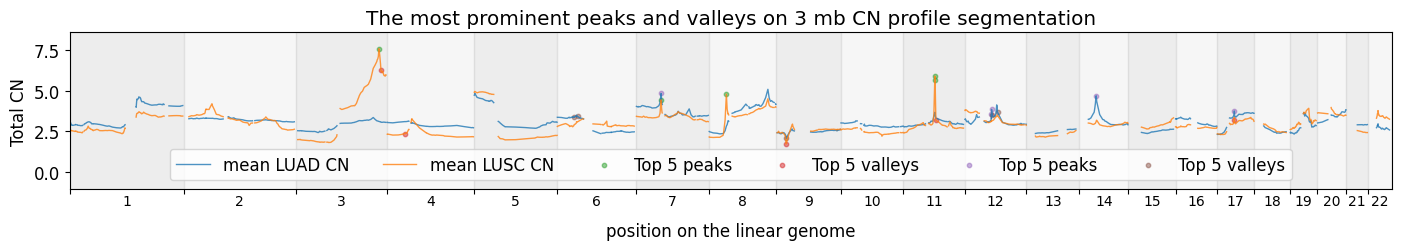

In [106]:
feature = "score"
val_count = 5
# indices of top 5 values

fig, ax = cns.fig_lines(pd.concat([lusc_df, luad_df]), cn_columns="total_cn", colors=[color_map[0], color_map[1]])
fig.set_size_inches(14, 2)

for i, sel_df in enumerate([lusc_df, luad_df]):
	sel_df = cns.add_cum_mid(sel_df)
	sel_df = sel_df[~sel_df["name"].str.startswith("chr")].sort_values(by="score")
	ax.scatter(sel_df["cum_mid"].head(5), sel_df["total_cn"].head(5), color=color_map[2 + i*2], alpha=0.5, s=10, label="Top 5 peaks")
	ax.scatter(sel_df["cum_mid"].tail(5), sel_df["total_cn"].tail(5), color=color_map[3 + i*2], alpha=0.5, s=10, label="Top 5 valleys")

plt.title("The most prominent peaks and valleys on 3 mb CN profile segmentation")
plt.ylabel("Total CN")

# legend with 3 columns
ax.legend(loc="lower center", ncol=6)

cdu.save_cns_fig("3MB_cns_peaks_valleys")